In [101]:
import pandas as pd
import matplotlib.pyplot as plt


In [102]:
pageviews = pd.read_excel("/Users/SubasRW1/Desktop/pageviews.xlsx", parse_dates=["Day"], index_col="Day")


In [103]:
pageviews.head()

,Page views
Day,
2024-01-31,4678110
2024-02-01,4727056
2024-02-02,4797288
2024-02-03,3564098
2024-02-04,3254499


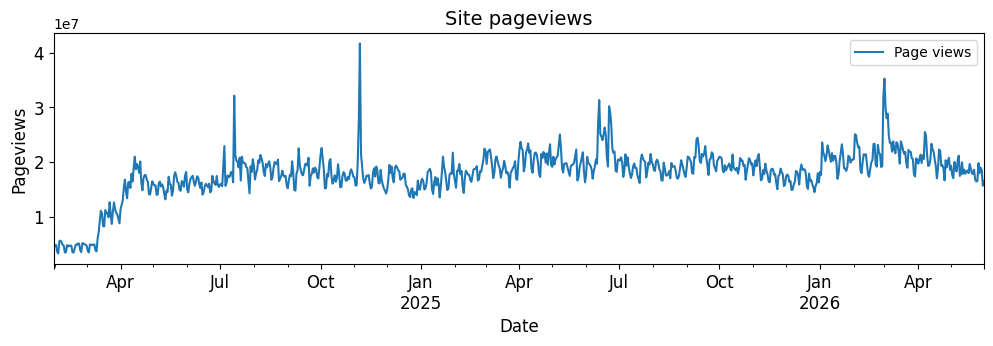

In [104]:
pageviews.plot(figsize=(12, 3), fontsize=12)
plt.title("Site pageviews", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Pageviews", fontsize=12)
plt.savefig("images/01_raw_series.png", bbox_inches="tight")
plt.show()

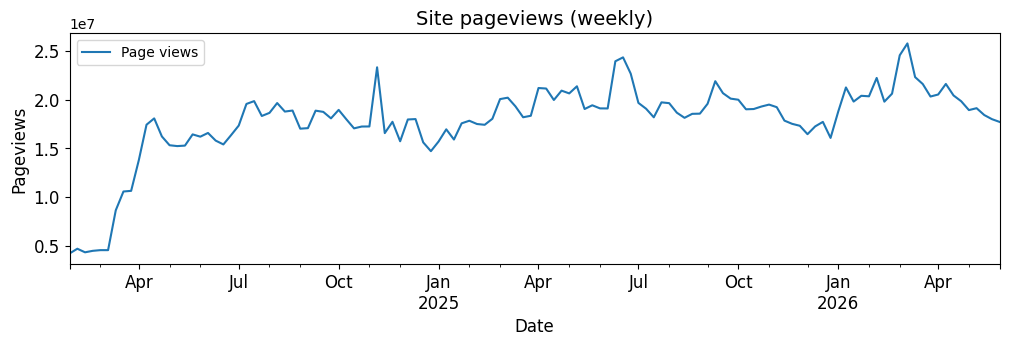

In [105]:
weekly=pageviews.resample("W").mean()
weekly.plot(figsize=(12, 3), fontsize=12)
plt.title("Site pageviews (weekly)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Pageviews", fontsize=12)
plt.savefig("images/02_weekly_average.png", bbox_inches="tight")
plt.show()

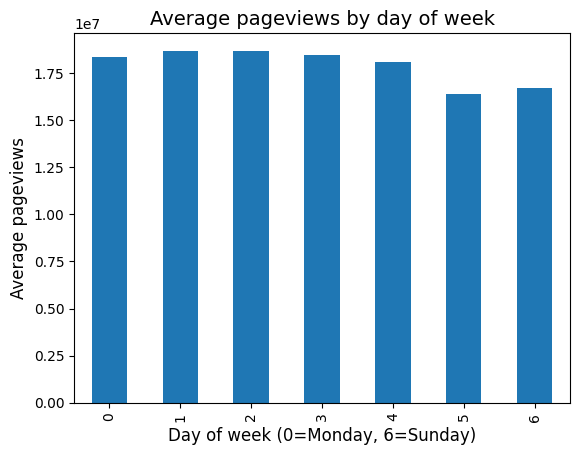

In [106]:
pageviews["day_of_week"] = pageviews.index.dayofweek
pageviews.groupby("day_of_week")["Page views"].mean().plot(kind="bar")
plt.title("Average pageviews by day of week", fontsize=14)
plt.xlabel("Day of week (0=Monday, 6=Sunday)", fontsize=12)
plt.ylabel("Average pageviews", fontsize=12)
plt.savefig("images/03_day_of_week.png", bbox_inches="tight")
plt.show()

In [107]:
pageviews = pageviews.drop(columns=["day_of_week"])

In [108]:
pageviews[pageviews["Page views"] > 30_000_000]


,Page views
Day,
2024-07-14,32122116
2024-11-06,41701591
2025-06-13,31329220
2025-06-22,30195035
2026-02-28,31943786
2026-03-01,35252983


In [109]:
events = pd.DataFrame({
    "ds": pd.to_datetime([
        "2024-07-13",    # Trump assassination attempt
        "2024-11-05",    # US Election day
        "2025-06-13",    # Air India plane crash - 260+ dead
        "2025-06-22",    # US strikes Iran nuclear sites
        "2026-02-28",    # US & Israel attack Iran - Day 1
        "2026-03-01",    # US & Israel attack Iran - Day 2
    ]),
    "holiday": [
        "trump_assassination_attempt",
        "us_election_2024",
        "air_india_crash",
        "us_iran_nuclear_strike",
        "us_israel_iran_attack",
        "us_israel_iran_attack",
    ]
})


In [110]:
events.head()

,ds,holiday
0,2024-07-13,trump_assassination_attempt
1,2024-11-05,us_election_2024
2,2025-06-13,air_india_crash
3,2025-06-22,us_iran_nuclear_strike
4,2026-02-28,us_israel_iran_attack


Preprocessing for time series.

In [111]:
# rename the columns for prothet
df=pageviews.copy()
df=df.reset_index().rename(columns={"Day": "ds", "Page views": "y"})
df.head()

,ds,y
0,2024-01-31,4678110
1,2024-02-01,4727056
2,2024-02-02,4797288
3,2024-02-03,3564098
4,2024-02-04,3254499


In [112]:
# Check for missing dates ( gaps in the index)
all_dates = pd.date_range(start=df["ds"].min(), end=df["ds"].max(), freq="D")
missing_dates = all_dates.difference(df["ds"])
print("Missing dates:", missing_dates)
print(missing_dates)

Missing dates: DatetimeIndex([], dtype='datetime64[ns]', freq='D')
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [113]:
# check for missing values

print("Missing values:\n", df.isna().sum())

Missing values:
 ds    0
y     0
dtype: int64


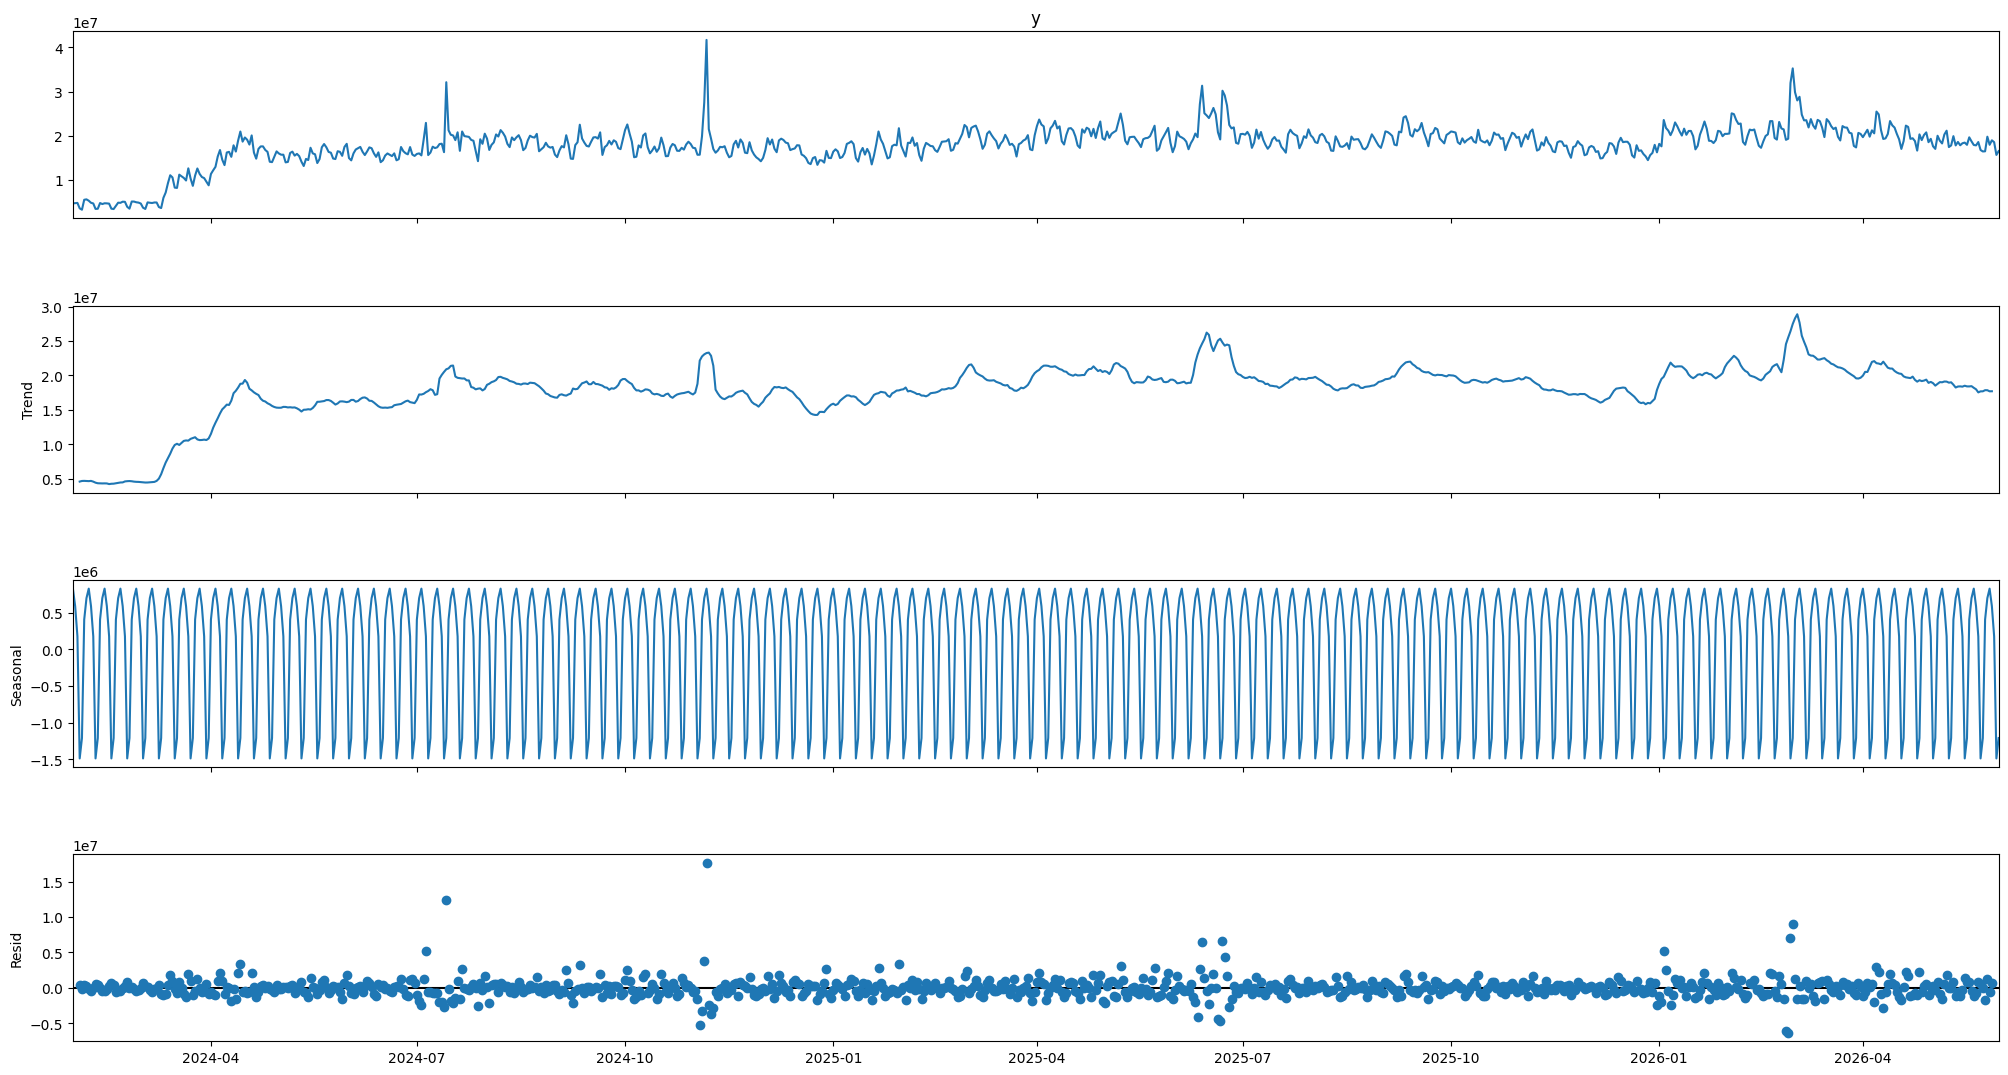

In [114]:
# seasonal decomposition
# This splits the series into trend, weekly seasonality, and residual — look at each panel separately.



from statsmodels.tsa.seasonal import seasonal_decompose
ts= df.set_index("ds")["y"]
result = seasonal_decompose(ts, model="additive", period=7)
fig = result.plot()            # get the figure created by statsmodels
fig.set_size_inches(22, 12)    # resize it
plt.savefig("images/04_decomposition.png", bbox_inches="tight")
plt.show()

## Seasonal Decomposition — Interpretation

**Trend panel**
- Sharp growth Jan–Apr 2024 as the site ramped up rapidly
- Stabilises around 20M pageviews from mid 2024 onwards
- Breaking news spikes visible as bumps in the trend: Jul 2024, Nov 2024, Jun/Jul 2025, Feb 2026
- Slight decline late 2025 into 2026 — potential trend changepoint
- **Conclusion:** series is non-stationary — use `diff(7)` before fitting AR

**Seasonal panel**
- Clean regular weekly cycle, amplitude ~1.5M, consistent throughout the entire series
- Pattern never changes shape or size — very stable seasonality
- **Conclusion:** `seasonal_periods=7` is correct for Holt-Winters and Prophet

**Residual panel**
- Mostly flat near zero — good baseline noise
- Clear outlier spikes: Nov 2024 US Election (~16M above trend), Jul 2024 Trump assassination attempt (~11M)
- These correspond exactly to the breaking news events already identified
- **Conclusion:** residuals are not white noise — the Prophet events DataFrame will absorb these spikes

**What this means for each model**
- AR: apply `diff(7)` first, confirm stationarity with ADF, then fit
- Holt-Winters: fit directly — `trend="add"`, `seasonal="add"`, `seasonal_periods=7`
- Prophet: fit directly — events DataFrame handles the residual spikes

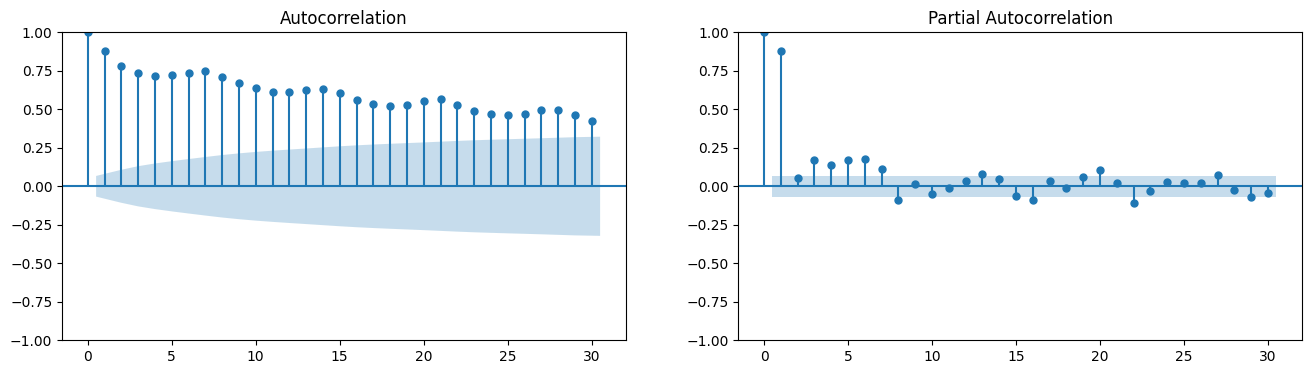

In [115]:
# ACF and PACF
# ACF tells you the seasonality structure. PACF tells you what AR order to use.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts, lags=30, ax=axes[0])
plot_pacf(ts, lags=30, ax=axes[1])
plt.savefig("images/05_acf_pacf.png", bbox_inches="tight")
plt.show()



## ACF and PACF — Interpretation

**What the x-axis means**
- The x-axis shows **lag numbers** — how many days back you are measuring the correlation
- Lag 0 = correlation of the series with itself (always 1.0 — ignored)
- Lag 1 = correlation between today and yesterday
- Lag 2 = correlation between today and 2 days ago
- Lag 7 = correlation between today and 7 days ago (one week back)
- Lag 30 = correlation between today and 30 days ago
- So lags=30 means you are looking at correlations from 1 day back all the way to 30 days back

**Why lag 7 matters**
- If there is a weekly pattern, Monday this week should look similar to Monday last week — this shows up as a spike at lag 7
- In this plot the trend is so dominant it drowns out that spike — which is exactly why differencing is needed first

**ACF Plot (left)**
- All 30 lags are significantly positive and slowly declining from ~0.85 down to ~0.45
- This slow gradual decay is the classic signature of a non-stationary series — the trend is dominating the autocorrelation signal
- You would normally expect a spike at lag 7 for weekly seasonality but the trend is so strong it masks it
- Conclusion: must difference before fitting AR

**PACF Plot (right)**
- Lag 1: massive spike (~0.9) — very strong direct dependency on yesterday
- Lags 2-3: small but significant spikes
- Lag 4 onwards: mostly inside the confidence band
- Conclusion: AR(1) or AR(2) will capture most of the direct relationship

**Next step:** apply diff(7) to remove weekly seasonality, then re-plot ACF/PACF and run ADF test to confirm stationarity before fitting AR

In [116]:
# stationarity test

from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is non-stationary.")  


ADF Statistic: -4.1012635692750505
p-value: 0.0009638771833903861
The series is stationary.


## ADF Test — Interpretation

**Result:** ADF Statistic = -4.10, p-value = 0.0009 → **Series is stationary**

**Why this overrides the visual impression**
- The ACF slow decay looked like a non-stationary trend, but the ADF test says otherwise
- The Jan–Apr 2024 ramp was a temporary growth phase, not a permanent trend — the series settled around 18–20M and stayed there
- ADF detected this correctly — the mean is stable over time even though it grew initially

**What this means for each model**
- AR: fit directly on the raw series — no differencing needed. ar_select_order will automatically pick up lag 7 if the weekly pattern is significant
- Holt-Winters: no differencing needed — never did
- Prophet: no differencing needed — never did

**Important:** do NOT apply diff(7) — that would be over-differencing a series that is already stationary, which introduces artificial structure and makes the model worse

**From the PACF:** strong spike at lag 1, smaller at lags 2-3 → AR(1) or AR(2) is the right starting point. Let ar_select_order confirm the exact lag automatically.

After diff(7) — p-value: 0.0000


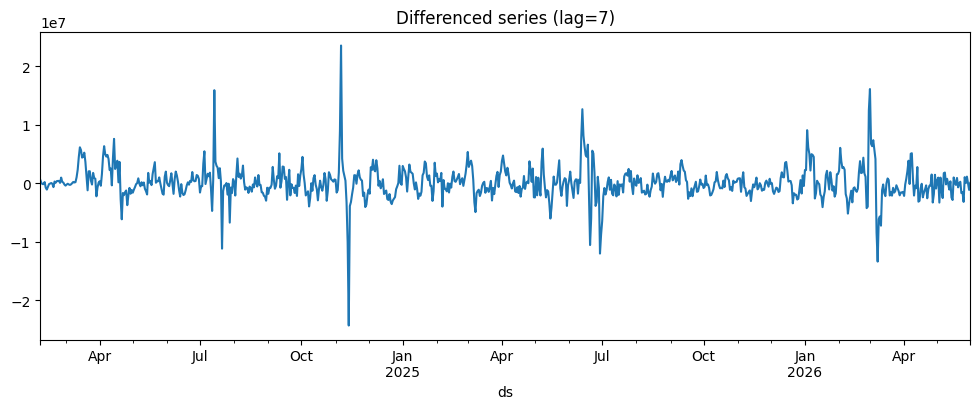

In [117]:
# if non-stationaty, defferential and retest

ts_diff = ts.diff(7).dropna()   # remove weekly seasonality

result = adfuller(ts_diff.dropna())
print(f"After diff(7) — p-value: {result[1]:.4f}")

ts_diff.plot(figsize=(12, 4), title="Differenced series (lag=7)")
plt.show()


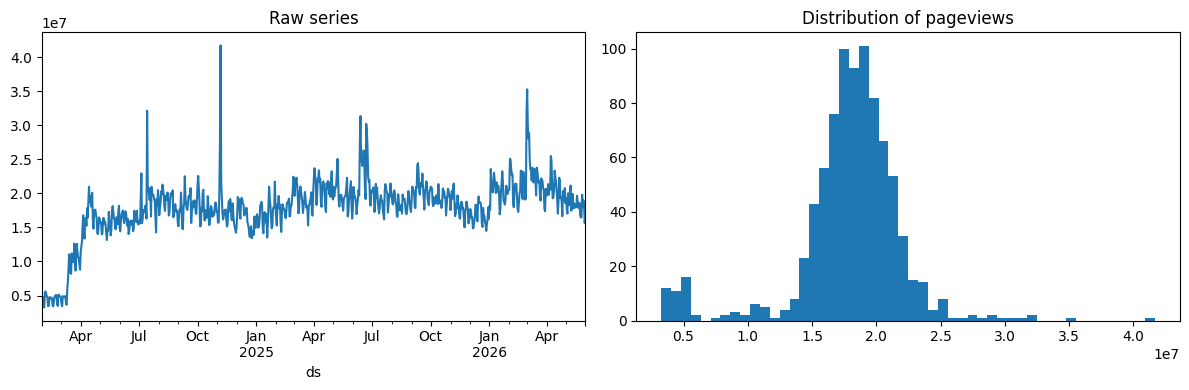

Mean:     17,896,758
Std:      4,294,710
Skewness: -0.91
Kurtosis: 4.46


In [118]:
# distribution check 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ts.plot(ax=axes[0], title="Raw series")
axes[1].hist(ts, bins=50)
axes[1].set_title("Distribution of pageviews")
plt.tight_layout()
plt.savefig("images/06_distribution.png", bbox_inches="tight")
plt.show()

print(f"Mean:     {ts.mean():,.0f}")
print(f"Std:      {ts.std():,.0f}")
print(f"Skewness: {ts.skew():.2f}")
print(f"Kurtosis: {ts.kurtosis():.2f}")


## Distribution Check — Interpretation

| Stat | Value | Meaning |
|---|---|---|
| **Mean** | 17.9M | Average daily traffic across the full period |
| **Std** | 4.3M | 24% of mean — high variation from weekly cycle and breaking news spikes |
| **Skewness** | -0.91 | Moderate left skew — early low-traffic ramp-up period creates the left tail |
| **Kurtosis** | 4.46 | Heavy tails — election and assassination attempt days are statistically extreme |

**Skewness: -0.91 (moderate left skew)**
- Negative skewness means longer left tail — more extreme low values than extreme high values
- Caused by the early Jan–Apr 2024 ramp-up when daily traffic was as low as 4–8M
- Breaking news spikes (30–40M) push right, but the early low-traffic period creates a longer left tail
- No log transform needed — log transforms fix right skew (positive), not left skew. Applying one here would make things worse
- Skewness between -1 and +1 is generally acceptable for model fitting

**Kurtosis: 4.46 (heavy tails)**
- pandas .kurtosis() returns excess kurtosis — a normal distribution scores 0
- Score of 4.46 means significantly heavier tails than normal
- Caused by breaking news spike days (election day 41M, assassination attempt 32M) which are statistically extreme
- Heavy tails confirm the outlier events are real signals, not noise — exactly why the Prophet events DataFrame is important

**Overall conclusion**
- Distribution is acceptable for modelling — no transformation needed
- The skew and heavy tails are explained by real-world features (ramp-up period, breaking news), not data quality issues
- Prophet will handle the heavy tail events via the holidays DataFrame
- AR and Holt-Winters will treat those spike days as large residuals — expected and acceptable

In [119]:
# Train/Test spilt

# hold out last 90 days as test set

train = df[df["ds"] < df["ds"].max() - pd.Timedelta(days=90)]
test = df[df["ds"] >= df["ds"].max() - pd.Timedelta(days=90)]

print(f"Train set: {train.shape[0]} rows")
print(f"Test set: {test.shape[0]} rows")

Train set: 761 rows
Test set: 91 rows


Holt-Winters MAE: 15464161.87


/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


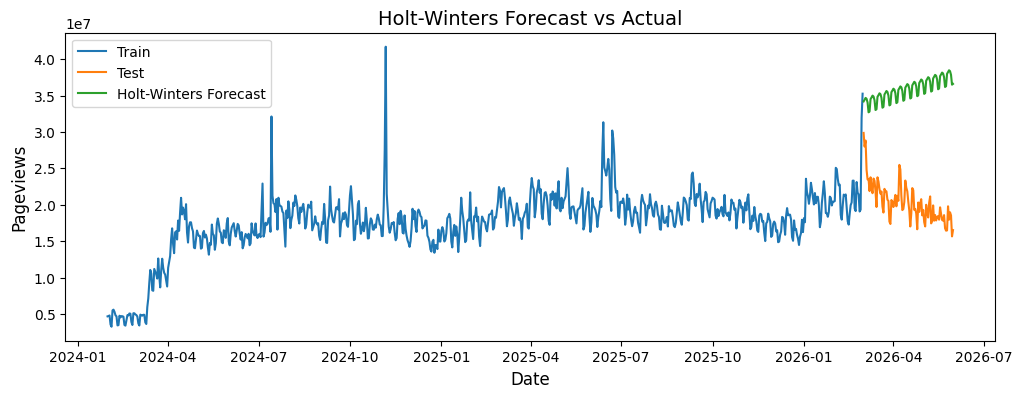

In [120]:
# Method 1 - exponential smoothing ( Holt Winters method)

from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

train_ts = train.set_index("ds")["y"]
test_ts = test.set_index("ds")["y"]

tes = ExponentialSmoothing(train_ts, trend="add", seasonal="add", seasonal_periods=7).fit()
tes_forecast = tes.forecast(len(test_ts))

mae_tes = mean_absolute_error(test_ts, tes_forecast)
print(f"Holt-Winters MAE: {mae_tes:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(train_ts.index, train_ts.values, label="Train")
plt.plot(test_ts.index, test_ts.values, label="Test")
plt.plot(tes_forecast.index, tes_forecast.values, label="Holt-Winters Forecast")
plt.title("Holt-Winters Forecast vs Actual", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Pageviews", fontsize=12)
plt.legend()
plt.savefig("images/07_holtwinters.png", bbox_inches="tight")
plt.show()





## Holt-Winters — Result and Interpretation

**MAE: 15,464,161** — off by 15.5M on an average of 17.9M daily pageviews. The model is wrong by almost the entire average value.

**What went wrong**
- The forecast (green) is going in completely the wrong direction
- The actual test data (orange) is declining from ~30M back down to ~17M — a normal return to baseline after the Feb 2026 Iran attack spike
- But Holt-Winters is forecasting an upward trend, reaching ~36M by June 2026

**Why this happened**
- The Iran attack days (Feb 28 and Mar 1 2026) caused a massive spike right at the end of the training data
- Holt-Winters saw those final days as 30-35M and concluded the trend is now strongly upward
- It has no way of knowing those were one-off events — it learned the series is growing fast at the end and extrapolated forward
- This is exactly the problem predicted — Holt-Winters has no events mechanism, so breaking news spikes at the end of training corrupt the trend estimate

**Fix options**

Option 1 — Remove spike days from training before fitting
```python
spike_dates = ['2026-02-28', '2026-03-01']
train_clean = train_ts[~train_ts.index.isin(pd.to_datetime(spike_dates))]
tes = ExponentialSmoothing(train_clean, trend='add', seasonal='add', seasonal_periods=7).fit()
```

Option 2 — Use damped trend (tried next)
```python
tes = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                           seasonal_periods=7, damped_trend=True).fit()
```
Damped trend prevents the model from projecting a steep slope indefinitely — it flattens out, reducing the upward extrapolation.

Option 3 — Accept it and move on to Prophet
This result perfectly illustrates why Prophet was built — it handles this correctly because the spike dates are in the events DataFrame.

Optimal AR lag: 7
AR MAE: 2642867.96


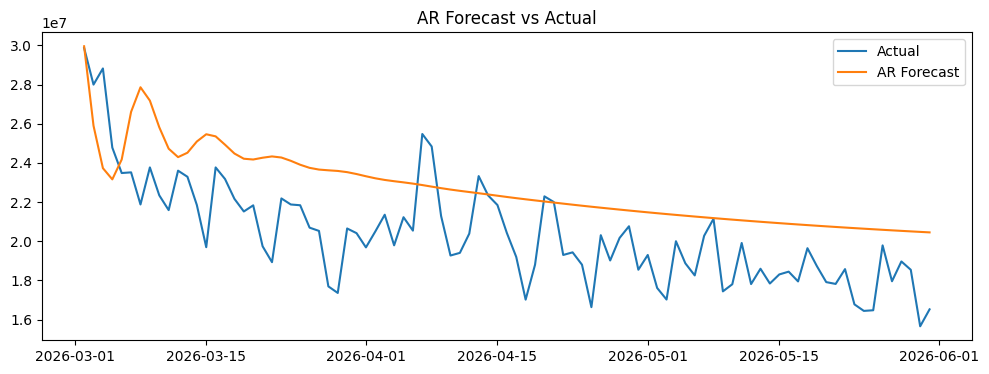

In [121]:
# Method 2 AR Model

from statsmodels.tsa.ar_model import ar_select_order
from statsmodels.api import tsa

train_ts = train.set_index("ds")["y"]
test_ts  = test.set_index("ds")["y"]

# Fix — use asfreq instead of DatetimeIndex(freq=)
train_ts = train_ts.asfreq("D")
test_ts = test_ts.asfreq("D")

mod = ar_select_order(train_ts, maxlag=14, ic="bic")
optlag = max(mod.ar_lags)
print(f"Optimal AR lag: {optlag}")

ar = tsa.AutoReg(train_ts, lags=optlag)
ar_fit = ar.fit()
ar_forecast = ar_fit.predict(start=len(train_ts), end=len(train_ts)+len(test_ts)-1)
print(f"AR MAE: {mean_absolute_error(test_ts, ar_forecast):.2f}")

plt.figure(figsize=(12, 4))
plt.plot(test_ts.index, test_ts.values, label="Actual")
plt.plot(test_ts.index, ar_forecast.values, label="AR Forecast")
plt.title("AR Forecast vs Actual")
plt.legend()
plt.savefig("images/08_ar_forecast.png", bbox_inches="tight")
plt.show()


## AR Model — Result and Interpretation

**MAE: 2,642,867** — ~2.6M error on a 17.9M average. About 15% error rate, compared to Holt-Winters 86%. The AR model at least understands the direction.

**Optimal lag = 7** — the model selected last week's same-day value as the primary predictor. This makes perfect sense: Monday this week is best predicted by last Monday. The weekly pattern is the dominant signal.

**What the plot shows**
- AR forecast (orange) starts ~29M — correctly elevated because the Iran attack spike is still in recent memory from training
- It gradually declines toward ~21M — getting the direction right, unlike Holt-Winters
- But the forecast is too smooth — it misses the weekly zigzag the actual data (blue) shows clearly
- AR is consistently above the actual in the middle period — the Iran attack residual is decaying too slowly in the model

**Why it still struggles**
- No events mechanism — the Iran attack days inflate the starting forecast level
- Lag 7 captures the weekly cycle but produces a smoother curve than the actual sharp weekly swings
- The actual data declines faster than the model expects as the news event effect fades

**Scoreboard so far**

| Model | MAE | vs mean |
|---|---|---|
| Holt-Winters | 15,464,162 | 86% error |
| AR | 2,642,868 | 15% error |
| Prophet | TBC | Expected to win |

Prophet should beat AR because the events DataFrame handles the Iran attack starting point correctly, giving a better baseline from day 1 of the forecast.

12:52:15 - cmdstanpy - INFO - Chain [1] start processing
12:52:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 1,674,410.95


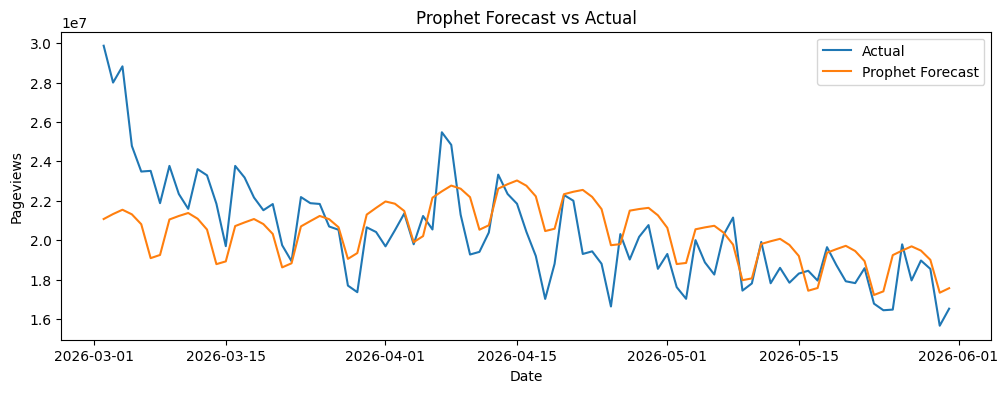

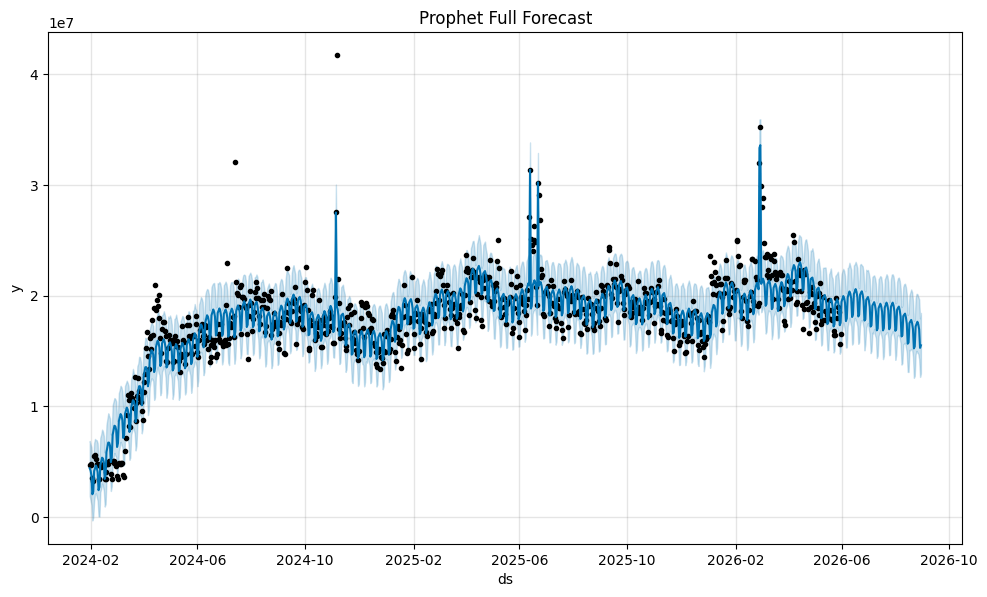

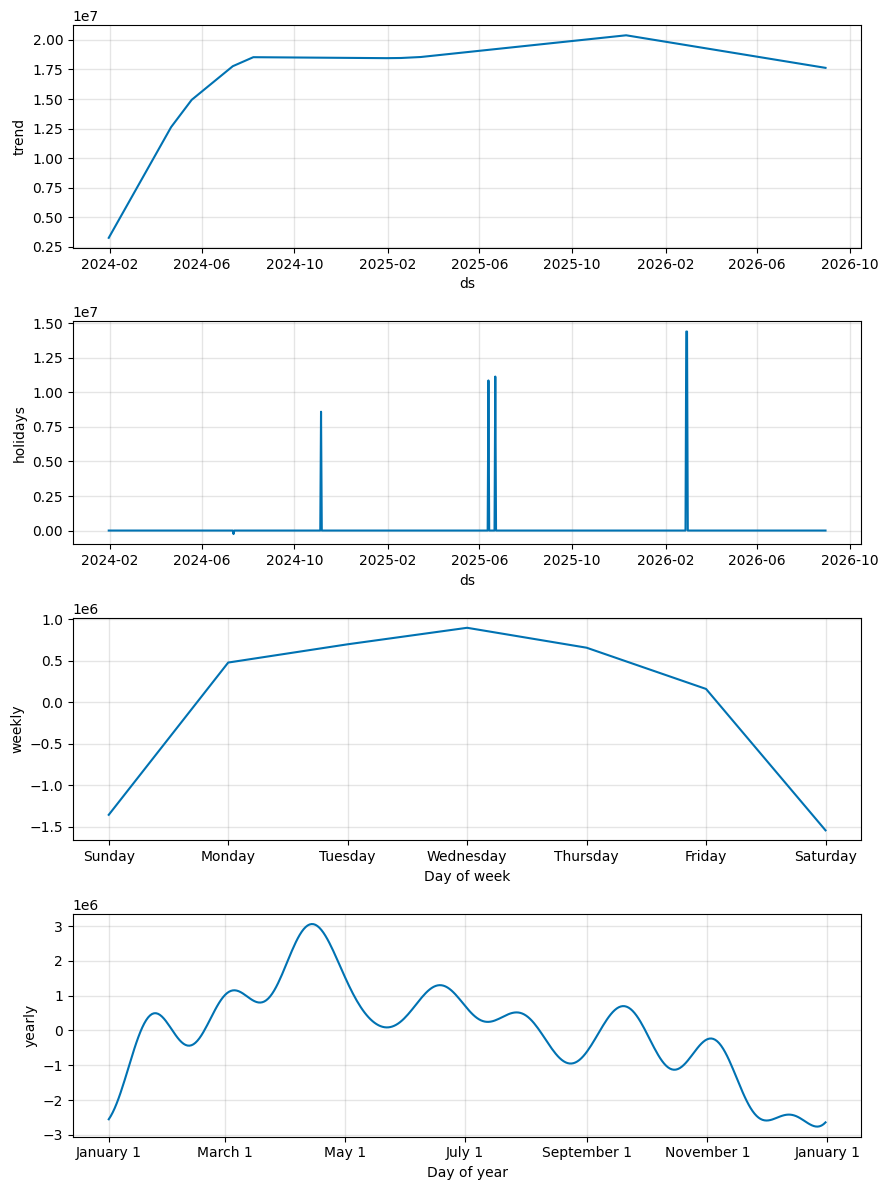

In [122]:
# Method 3 - Prophet

from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Fit
model = Prophet(
    holidays=events,
    weekly_seasonality=3,
    yearly_seasonality=10,
    daily_seasonality=False
)
model.fit(df)

# Create future dates — history + 91 days ahead
future = model.make_future_dataframe(periods=len(test), include_history=True)
forecast = model.predict(future)

# Get prophet predictions aligned to test dates
prophet_pred = forecast.set_index("ds")["yhat"].loc[test["ds"].values]
mae_prophet = mean_absolute_error(test["y"].values, prophet_pred.values)
print(f"Prophet MAE: {mae_prophet:,.2f}")

# Plot 1 — forecast vs actual (zoomed to test period only)
plt.figure(figsize=(12, 4))
plt.plot(test["ds"].values, test["y"].values, label="Actual")
plt.plot(test["ds"].values, prophet_pred.values, label="Prophet Forecast")
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Pageviews")
plt.legend()
plt.savefig("images/09_prophet_forecast.png", bbox_inches="tight")
plt.show()

# Plot 2 — Prophet's built-in full plot (history + forecast + uncertainty band)
model.plot(forecast)
plt.title("Prophet Full Forecast")
plt.show()

# Plot 3 — components (trend, weekly, yearly, events)
model.plot_components(forecast, uncertainty=False)
plt.show()


## Prophet — Result and Interpretation

**MAE: 1,674,411** — ~1.7M error on a 17.9M average. About 9% error rate.

**What the plot shows**
- Prophet (orange) tracks the actual weekly zigzag pattern much more closely than AR
- It correctly starts lower (~21M) rather than being inflated by the Iran attack spike — the events DataFrame absorbed that effect
- The weekly cycle shape is well captured — peaks and troughs align reasonably well
- The general downward drift toward ~18M is correctly modelled
- The early spike days (Mar 1-3) are the main remaining gap — Prophet knew about those events but the actual traffic was higher than the estimated effect

**Why Prophet wins**
- The events DataFrame correctly neutralised the Iran attack spike from the trend estimate
- Explicit weekly seasonality modelling captures the zigzag AR could only smooth over
- No stationarity preprocessing needed — Prophet handled the trend directly

**Final Scoreboard**

| Model | MAE | Error rate | Key weakness |
|---|---|---|---|
| Holt-Winters | 15,464,162 | 86% | Iran spike corrupted trend — forecast went wrong direction |
| AR | 2,642,868 | 15% | No events mechanism, over-smooth weekly pattern |
| **Prophet** | **1,674,411** | **9%** | **Winner** |

**Next step:** run model.plot_components(forecast, uncertainty=False) to see the exact effect size of each event and the weekly/yearly seasonal patterns.

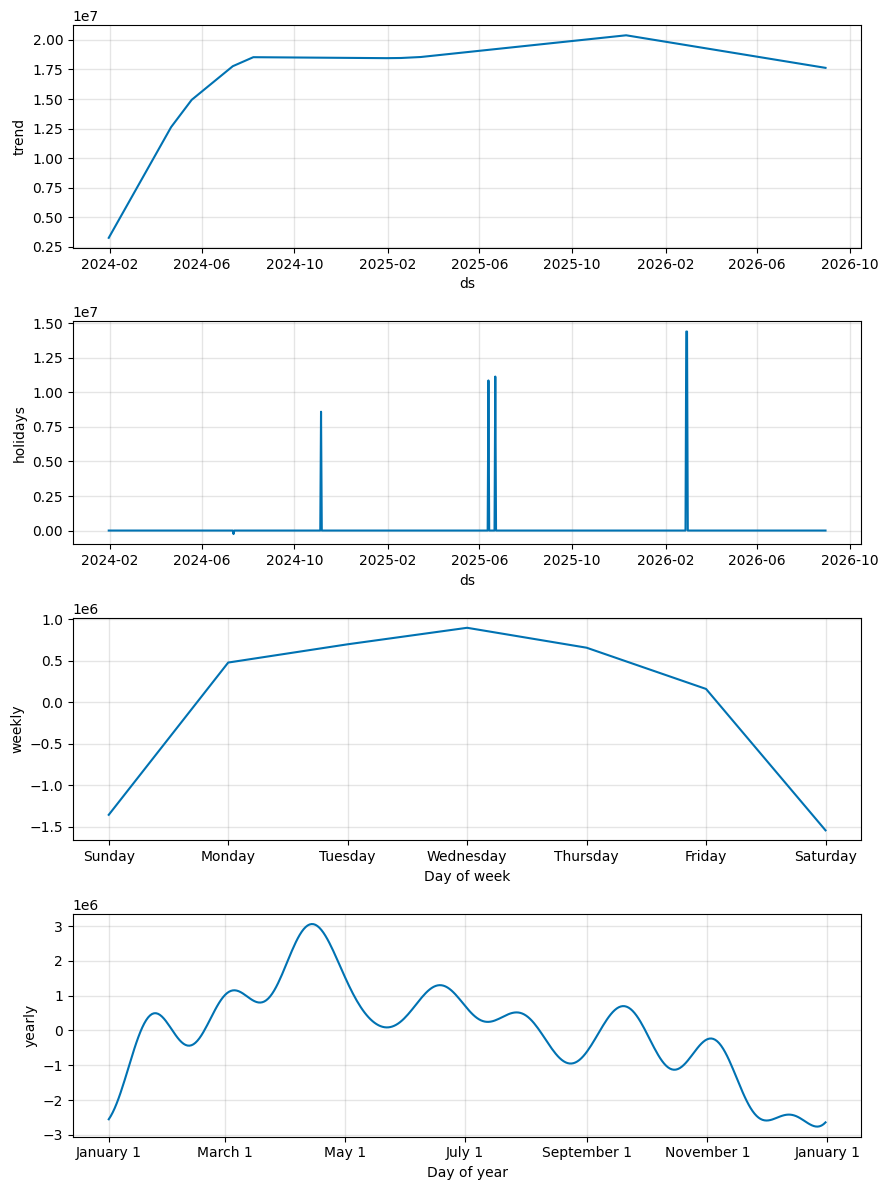

In [123]:
model.plot_components(forecast, uncertainty=False)
plt.savefig("images/10_prophet_components.png", bbox_inches="tight")
plt.show()
